In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 128
latent_dim = 20
epochs = 10
lr = 1e-3


In [17]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [18]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim):
        super(ConvVAE, self).__init__()
        # Encoder
        self.enc_conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # 14x14
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1) # 7x7
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)
        self.dec_conv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 14x14
        self.dec_conv2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)   # 28x28

    def encode(self, x):
        x = F.relu(self.enc_conv1(x))
        x = F.relu(self.enc_conv2(x))
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = F.relu(self.fc_decode(z))
        x = x.view(-1, 64, 7, 7)
        x = F.relu(self.dec_conv1(x))
        x = torch.sigmoid(self.dec_conv2(x))
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [19]:
def loss_function(recon_x, x, mu, logvar, loss_type='bce'):
    if loss_type == 'bce':
        recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    elif loss_type == 'mse':
        recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    else:
        raise ValueError("Unknown loss type")

    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div


In [20]:
def train_vae(model, optimizer, train_loader, loss_type):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = loss_function(recon, x, mu, logvar, loss_type)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader.dataset)


In [21]:
vae_bce = ConvVAE(latent_dim).to(device)
vae_mse = ConvVAE(latent_dim).to(device)

optimizer_bce = optim.Adam(vae_bce.parameters(), lr=lr)
optimizer_mse = optim.Adam(vae_mse.parameters(), lr=lr)


In [22]:
bce_losses = []
mse_losses = []

for epoch in range(epochs):
    bce_loss = train_vae(vae_bce, optimizer_bce, train_loader, loss_type='bce')
    mse_loss = train_vae(vae_mse, optimizer_mse, train_loader, loss_type='mse')
    bce_losses.append(bce_loss)
    mse_losses.append(mse_loss)
    print(f"Epoch {epoch+1}, BCE Loss: {bce_loss:.2f}, MSE Loss: {mse_loss:.2f}")


Epoch 1, BCE Loss: 169.84, MSE Loss: 48.73
Epoch 2, BCE Loss: 113.98, MSE Loss: 33.23
Epoch 3, BCE Loss: 108.59, MSE Loss: 31.66
Epoch 4, BCE Loss: 106.44, MSE Loss: 31.01
Epoch 5, BCE Loss: 105.11, MSE Loss: 30.55
Epoch 6, BCE Loss: 104.26, MSE Loss: 30.25
Epoch 7, BCE Loss: 103.54, MSE Loss: 30.02
Epoch 8, BCE Loss: 103.04, MSE Loss: 29.79
Epoch 9, BCE Loss: 102.55, MSE Loss: 29.59
Epoch 10, BCE Loss: 102.13, MSE Loss: 29.45


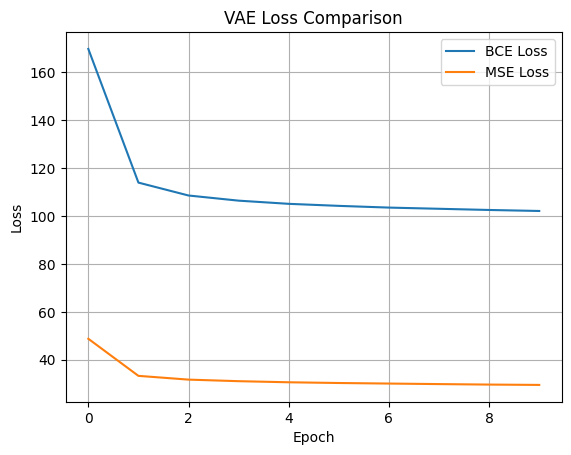

In [23]:
plt.plot(bce_losses, label='BCE Loss')
plt.plot(mse_losses, label='MSE Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()


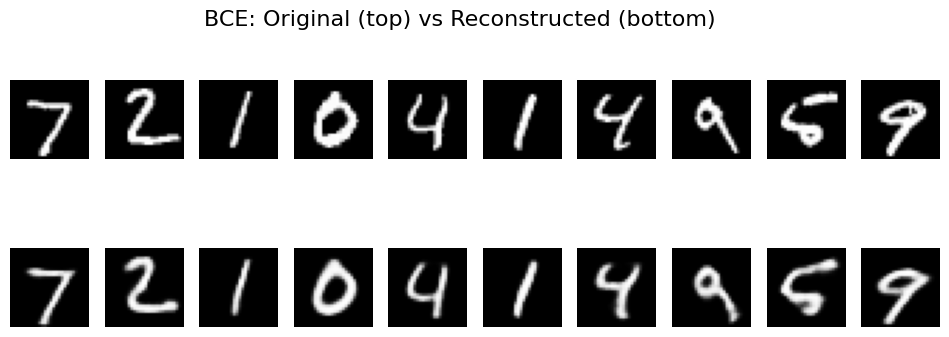

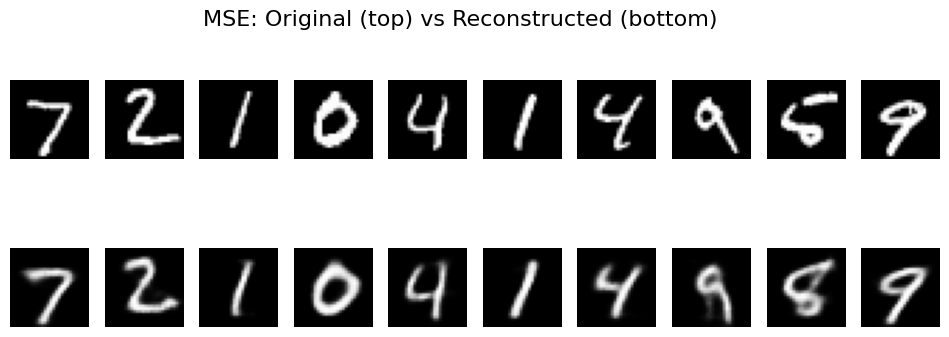

In [24]:
def show_reconstructions(model, data_loader, loss_type, title):
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(data_loader))
        x = x.to(device)
        recon, _, _ = model(x)
        x = x.cpu().numpy()
        recon = recon.cpu().numpy()

        plt.figure(figsize=(12, 4))
        for i in range(10):
            # Original
            plt.subplot(2, 10, i+1)
            plt.imshow(x[i][0], cmap='gray')
            plt.axis('off')

            # Reconstructed
            plt.subplot(2, 10, i+11)
            plt.imshow(recon[i][0], cmap='gray')
            plt.axis('off')

        plt.suptitle(title, fontsize=16)
        plt.show()

show_reconstructions(vae_bce, test_loader, 'bce', "BCE: Original (top) vs Reconstructed (bottom)")
show_reconstructions(vae_mse, test_loader, 'mse', "MSE: Original (top) vs Reconstructed (bottom)")
